In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vanatejitha/tejitha/wdbc.names
/kaggle/input/datasets/vanatejitha/tejitha/wdbc.data


In [2]:
# ==========================================================
# Feedforward Neural Network (FFNN)
# Breast Cancer Wisconsin Diagnostic Dataset
# Input Layer  : 20 Features
# Hidden Layers: 5 Hidden Layers (10 Neurons each, ReLU)
# Output Layer : 1 Neuron (Sigmoid)
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# ==========================================================
# Check TensorFlow Version
# ==========================================================

print("TensorFlow Version :", tf.__version__)
print("Available GPUs :", tf.config.list_physical_devices('GPU'))

# ==========================================================
# Load Dataset
# ==========================================================

# Change the path if required
df = pd.read_csv(
    "/kaggle/input/datasets/vanatejitha/tejitha/wdbc.data",
    header=None
)

# ==========================================================
# Display Dataset Information
# ==========================================================

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

# ==========================================================
# Data Preprocessing
# ==========================================================

# First 20 features
X = df.iloc[:, 2:22].values

# Target Variable
# M = Malignant = 1
# B = Benign = 0

y = df.iloc[:, 1].map({'M': 1, 'B': 0}).values

# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# Build Feedforward Neural Network
# ==========================================================

model = Sequential([

    Input(shape=(20,)),

    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),

    Dense(1, activation='sigmoid')

])

# ==========================================================
# Compile Model
# ==========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# Model Summary
# ==========================================================

print("\nModel Summary")
model.summary()

# ==========================================================
# Train Model
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

# ==========================================================
# Evaluate Model
# ==========================================================

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("Test Loss     :", loss)
print("Test Accuracy :", accuracy)
print("==============================")

# ==========================================================
# Predictions
# ==========================================================

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

# ==========================================================
# Performance Metrics
# ==========================================================

print("\nAccuracy Score")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# ==========================================================
# Display Total Parameters
# ==========================================================

print("\nTotal Trainable Parameters:", model.count_params())

TensorFlow Version : 2.20.0
Available GPUs : []

First Five Rows
         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

   

2026-07-17 15:05:28.198898: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661 (2.58 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7143 - loss: 0.6738 - val_accuracy: 0.7582 - val_loss: 0.6505
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7967 - loss: 0.6095 - val_accuracy: 0.8352 - val_loss: 0.5537
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8489 - loss: 0.4977 - val_accuracy: 0.8571 - val_loss: 0.4250
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8874 - loss: 0.3860 - val_accuracy: 0.8901 - val_loss: 0.3319
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9148 - loss: 0.3007 - val_accuracy: 0.9231 - val_loss: 0.2720
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9231 - loss: 0.2385 - val_accuracy: 0.9121 - val_loss: 0.2517
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9368 - loss: 0.1979 - val_accuracy: 0.9121 - val_loss: 0.2363
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9341 - loss: 0.1739 - val_accuracy: 0.9341 - val_loss

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4670 - loss: 0.7341 - val_accuracy: 0.5165 - val_loss: 0.6961
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5082 - loss: 0.7098 - val_accuracy: 0.6593 - val_loss: 0.6919
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5522 - loss: 0.7118 - val_accuracy: 0.6923 - val_loss: 0.6894
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5549 - loss: 0.7053 - val_accuracy: 0.6923 - val_loss: 0.6861
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5549 - loss: 0.6828 - val_accuracy: 0.6703 - val_loss: 0.6806
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5852 - loss: 0.6733 - val_accuracy: 0.6703 - val_loss: 0.6733
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5824 - loss: 0.6880 - val_accuracy: 0.6703 - val_loss: 0.6646
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5907 - loss: 0.6637 - val_accuracy: 0.6813 - 

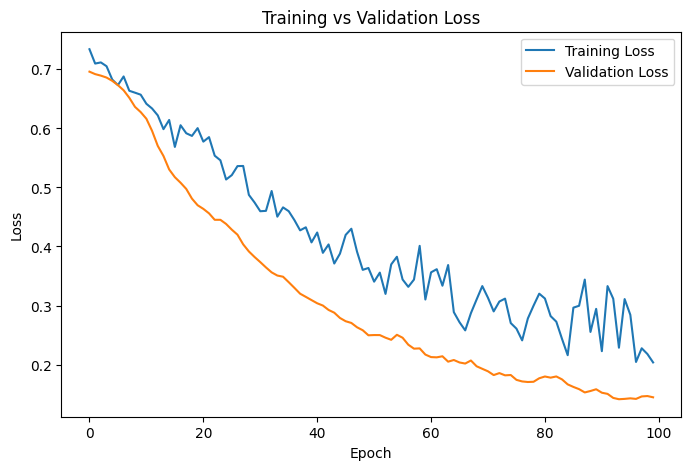

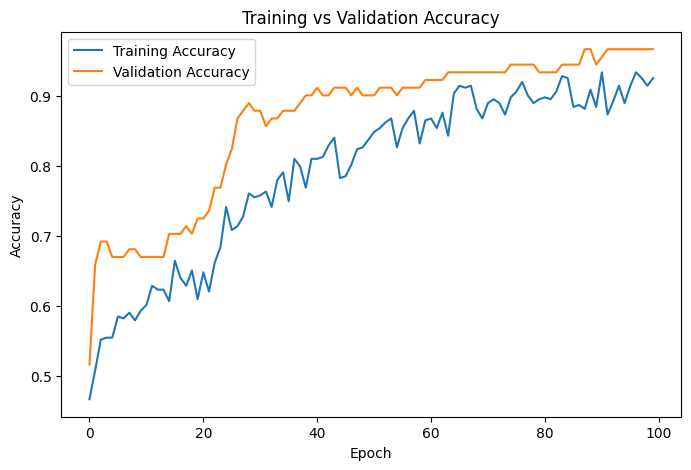

In [3]:
# ==========================================================
# FFNN with Batch Normalization, Dropout and Early Stopping
# Breast Cancer Wisconsin Diagnostic Dataset
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(
    "/kaggle/input/datasets/vanatejitha/tejitha/wdbc.data",
    header=None
)

# ==========================================================
# Data Preprocessing
# ==========================================================

# Select first 20 features
X = df.iloc[:, 2:22].values

# Target Variable
y = df.iloc[:, 1].map({'M':1,'B':0}).values

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardization

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# Build Improved FFNN
# ==========================================================

model = Sequential([

    Input(shape=(20,)),

    Dense(10),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.2),

    Dense(10),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.2),

    Dense(10),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.2),

    Dense(10),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.2),

    Dense(10),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')

])

# ==========================================================
# Compile Model
# ==========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# Early Stopping
# ==========================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ==========================================================
# Train Model
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# Evaluate Model
# ==========================================================

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)

# ==========================================================
# Predictions
# ==========================================================

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

print("\nAccuracy Score")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# ==========================================================
# Plot Loss Curves
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# ==========================================================
# Plot Accuracy Curves
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [5]:
# ==========================================================
# Comparative Analysis
# Optimizers: SGD vs Adam
# Loss Functions: BCE vs MSE
# ==========================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv(
    "/kaggle/input/datasets/vanatejitha/tejitha/wdbc.data",
    header=None
)

# ==========================================================
# Data Preprocessing
# ==========================================================

X = df.iloc[:, 2:22].values
y = df.iloc[:, 1].map({'M':1,'B':0}).values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# Function to Build Model
# ==========================================================

def create_model():

    model = Sequential([

        Input(shape=(20,)),

        Dense(10),
        BatchNormalization(),
        tf.keras.layers.ReLU(),
        Dropout(0.2),

        Dense(10),
        BatchNormalization(),
        tf.keras.layers.ReLU(),
        Dropout(0.2),

        Dense(10),
        BatchNormalization(),
        tf.keras.layers.ReLU(),
        Dropout(0.2),

        Dense(10),
        BatchNormalization(),
        tf.keras.layers.ReLU(),
        Dropout(0.2),

        Dense(10),
        BatchNormalization(),
        tf.keras.layers.ReLU(),
        Dropout(0.2),

        Dense(1, activation='sigmoid')

    ])

    return model

# ==========================================================
# Configurations
# ==========================================================

configs = {

    "SGD + MSE": (
        tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        "mse"
    ),

    "SGD + BCE": (
        tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        "binary_crossentropy"
    ),

    "Adam + MSE": (
        tf.keras.optimizers.Adam(),
        "mse"
    ),

    "Adam + BCE": (
        tf.keras.optimizers.Adam(),
        "binary_crossentropy"
    )

}

results = []

# ==========================================================
# Train Each Configuration
# ==========================================================

for name, (optimizer, loss_function) in configs.items():

    print("\n======================================")
    print(name)
    print("======================================")

    model = create_model()

    model.compile(
        optimizer=optimizer,
        loss=loss_function,
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.20,
        callbacks=[early_stop],
        verbose=0
    )

    # Test Accuracy
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Epochs Used
    epochs_used = len(history.history['loss'])

    results.append([
        name,
        epochs_used,
        history.history['loss'][-1],
        history.history['val_loss'][-1],
        accuracy
    ])

# ==========================================================
# Comparative Table
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Configuration",
        "Epochs to Converge",
        "Final Training Loss",
        "Final Validation Loss",
        "Final Test Accuracy"
    ]
)

print("\n================ Comparative Results ================\n")
print(results_df)

# Optional: Save Results
results_df.to_csv("comparison_results.csv", index=False)


SGD + MSE

SGD + BCE

Adam + MSE

Adam + BCE

================ Comparative Results ================

  Configuration  Epochs to Converge  Final Training Loss  \
0     SGD + MSE                  72             0.072127   
1     SGD + BCE                  41             0.254105   
2    Adam + MSE                  76             0.083694   
3    Adam + BCE                 100             0.268204   

   Final Validation Loss  Final Test Accuracy  
0               0.037972             0.956140  
1               0.135782             0.947368  
2               0.043269             0.929825  
3               0.137368             0.956140  


Test Loss : 0.12203013896942139
Test Accuracy : 0.9561403393745422
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7dfa3374bd80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


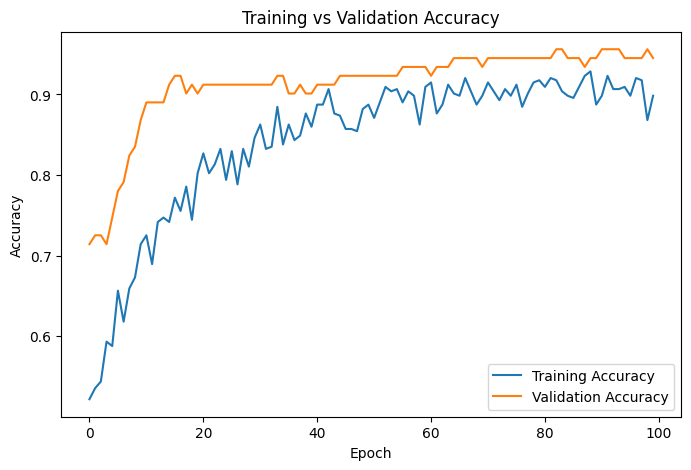

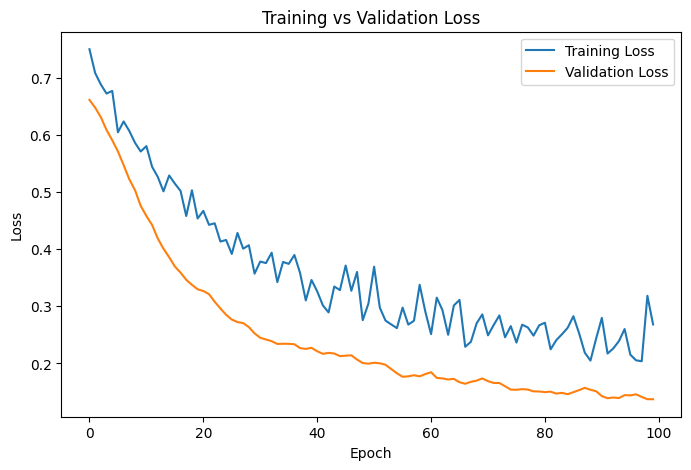


Confusion Matrix
[[71  1]
 [ 4 38]]

True Negatives : 71
False Positives: 1
False Negatives: 4
True Positives : 38


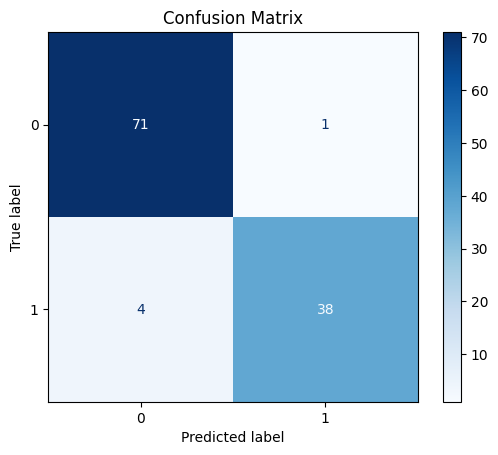


Precision  : 0.9743589743589743
Recall     : 0.9047619047619048
Sensitivity: 0.9047619047619048
Specificity: 0.9861111111111112
F1 Score   : 0.9382716049382716


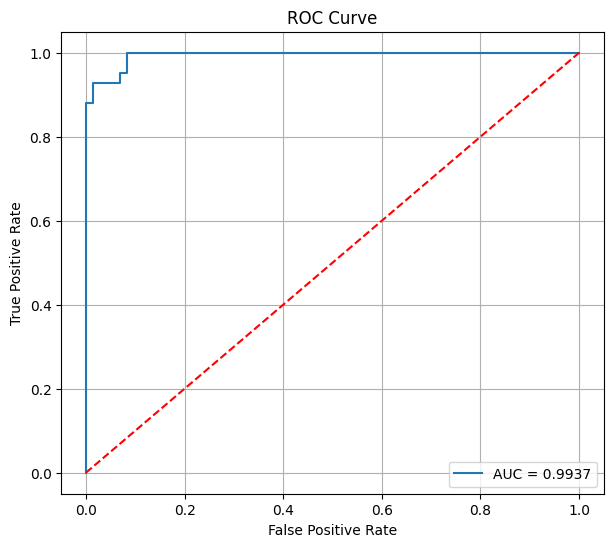


ROC-AUC Score : 0.9937169312169312

================ Final Results ================
Accuracy     : 0.956140350877193
Precision    : 0.9743589743589743
Recall       : 0.9047619047619048
Specificity  : 0.9861111111111112
F1 Score     : 0.9382716049382716
ROC-AUC      : 0.9937169312169312


In [6]:
# ==========================================================
# ADVANCED PERFORMANCE EVALUATION
# Use the best trained model
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

# ==========================================================
# Test Evaluation
# ==========================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# ==========================================================
# Predictions
# ==========================================================

y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

# ==========================================================
# Accuracy Curves
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

# ==========================================================
# Loss Curves
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# Clinical Metrics
# ==========================================================

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, y_pred)

print("\n==============================")
print("Precision  :", precision)
print("Recall     :", recall)
print("Sensitivity:", recall)
print("Specificity:", specificity)
print("F1 Score   :", f1)
print("==============================")

# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         label="AUC = {:.4f}".format(auc_score))

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print("\nROC-AUC Score :", auc_score)

# ==========================================================
# Summary
# ==========================================================

print("\n================ Final Results ================")

print("Accuracy     :", accuracy_score(y_test,y_pred))

print("Precision    :", precision)

print("Recall       :", recall)

print("Specificity  :", specificity)

print("F1 Score     :", f1)

print("ROC-AUC      :", auc_score)

print("==============================================")